1. Criar API token no kaggle
2. mkdir -p ~/.kaggle
3. Criar arquivo kaggle.json na pasta .kaggle
4. Escrever em kaggle.json {"username":"seu_usuario","key":"123456789abcde..."}
5. chmod 600 ~/.kaggle/kaggle.json
6. Reiniciar o kernel


In [8]:
import torch
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import copy
import json


In [9]:
def set_seed(seed=42):
    """
    Congela a aleatoriedade de todas as bibliotecas para garantir a reprodutibilidade.
    """
    # 1. Congela o Python nativo
    random.seed(seed)
    
    # 2. Congela o NumPy 
    np.random.seed(seed)
    
    # 3. Congela o PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 4. Congela o PyTorch (GPU/CUDA) 
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        
        # Força o cuDNN a ser determinístico (pode deixar o treino levemente mais lento, mas é 100% reproduzível)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Chamamos a função passando um número arbitrário (42 é a tradição na comunidade de ML)
set_seed(42)

In [10]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('histopathologic-cancer-detection')

print("Path to competition files:", path)

Path to competition files: /home/thiago/.cache/kagglehub/competitions/histopathologic-cancer-detection


In [11]:
pastas_baixadas = os.listdir(path)
print("Conteúdo da pasta raiz:", pastas_baixadas)

Conteúdo da pasta raiz: ['train', 'sample_submission.csv', 'test', 'train_labels.csv']


In [12]:
# 1. CRIANDO A CLASSE DO DATASET CUSTOMIZADO
class HistopathologicDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        """
        dataframe: Pandas DataFrame contendo as colunas 'id' e 'label'
        img_dir: Caminho para a pasta contendo as imagens
        transform: Transformações do torchvision.transforms
        """
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # O Kaggle fornece os IDs sem a extensão, então adicionamos '.tif'
        img_name = self.dataframe.iloc[idx, 0] + '.tif'
        img_path = os.path.join(self.img_dir, img_name)
        
        # Abre a imagem e converte para RGB (caso haja alguma em escala de cinza/RGBA)
        image = Image.open(img_path).convert('RGB')
        
        # Pega o rótulo da imagem (0 ou 1)
        label = int(self.dataframe.iloc[idx, 1])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label


# Tamanhos definidos
CROP_SIZE = 48  # Mantém o centro seguro e descarta as bordas distantes
IMG_SIZE = 224  # Tamanho esperado pela ViT

# Médias e Desvios Padrões do dataset ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Pipeline de TREINO
train_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),        # 1º: Recorta de 96x96 para 64x64
#    transforms.Resize((IMG_SIZE, IMG_SIZE)), # 2º: Faz o upscaling para 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # 3º: Data Augmentation
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),                   # 4º: Converte para Tensor
    transforms.Normalize(mean, std)          # 5º: Normaliza
])

# Pipeline de VALIDAÇÃO e TESTE
test_val_transforms = transforms.Compose([
    transforms.CenterCrop(CROP_SIZE),        # 1º: Recorta de 96x96 para 64x64
#    transforms.Resize((IMG_SIZE, IMG_SIZE)), # 2º: Faz o upscaling para 224x224
    transforms.ToTensor(),                   # 3º: Converte para Tensor
    transforms.Normalize(mean, std)          # 4º: Normaliza
])  

# 3. CARREGANDO E DIVIDINDO OS DADOS COM PANDAS
data_dir = path
train_dir = os.path.join(data_dir, 'train')
csv_path = os.path.join(data_dir, 'train_labels.csv')

# Lê o CSV com os IDs e os labels
df = pd.read_csv(csv_path)

# Usamos o scikit-learn para dividir o DataFrame (90% treino, 10% validação)
# O parâmetro 'stratify' garante que a proporção de câncer/não-câncer seja mantida na validação
df_train, df_val = train_test_split(df, test_size=0.10, random_state=42, stratify=df['label'])

# Resetar os índices para evitar problemas no DataLoader
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

# 4. INSTANCIANDO OS DATASETS CUSTOMIZADOS
train_dataset = HistopathologicDataset(dataframe=df_train, img_dir=train_dir, transform=train_transforms)
val_dataset = HistopathologicDataset(dataframe=df_val, img_dir=train_dir, transform=test_val_transforms)

# 5. CONFIGURANDO OS DATALOADERS
BATCH_SIZE = 256

num_amostras_treino = int(len(train_dataset) * 0.1) # 10% do total
indices_treino = np.random.choice(len(train_dataset), num_amostras_treino, replace=False)

# Criamos um dataset "menor" (subset)
subset_train_dataset = Subset(train_dataset, indices_treino)

print(f"Treinando RÁPIDO apenas em 10% dos dados: {len(subset_train_dataset)} imagens")

train_loader = DataLoader(subset_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total de imagens no CSV: {len(df)}")
print(f"Treino: {len(train_dataset)} | Validação: {len(val_dataset)}")

Treinando RÁPIDO apenas em 10% dos dados: 19802 imagens
Total de imagens no CSV: 220025
Treino: 198022 | Validação: 22003


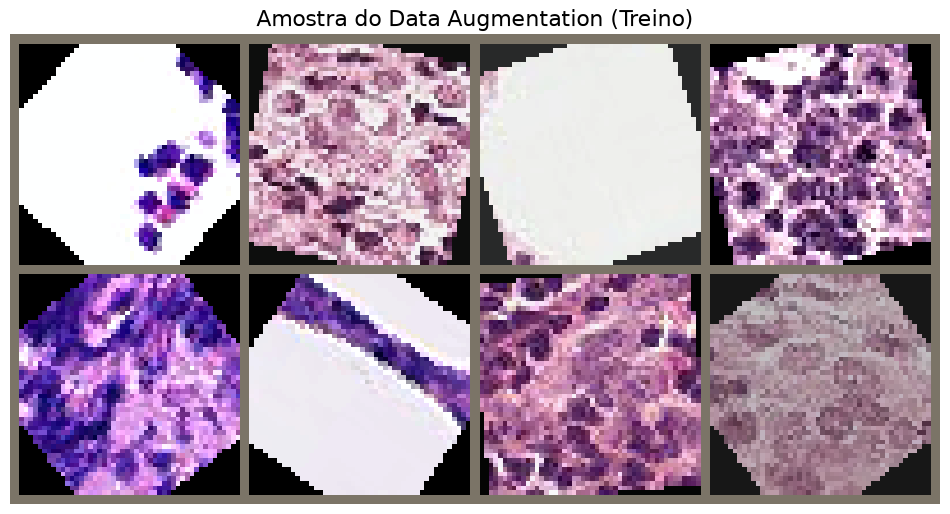

Rótulos correspondentes ao Grid (Esquerda para Direita):
Normal (0)      | Normal (0)      | Normal (0)      | Normal (0)     
Normal (0)      | Tumor (1)       | Normal (0)      | Tumor (1)      


In [13]:
def visualizar_batch(dataloader, num_imagens=8):
    """
    Extrai um batch do dataloader, desfaz a normalização e plota as imagens 
    em um grid com seus respectivos rótulos.
    """
    # 1. Extrai um lote (batch) de imagens e rótulos do DataLoader
    images, labels = next(iter(dataloader))
    
    images = images[:num_imagens]
    labels = labels[:num_imagens]
    
    # 2. Cria um grid de imagens usando o torchvision
    # nrow=4 significa que teremos 4 imagens por linha
    grid = torchvision.utils.make_grid(images, nrow=4, padding=2)
    
    # 3. Prepara o tensor para o Matplotlib
    # O PyTorch usa o formato [Canais, Altura, Largura] (C, H, W)
    # O Matplotlib exige o formato [Altura, Largura, Canais] (H, W, C)
    np_grid = grid.numpy()
    np_grid = np.transpose(np_grid, (1, 2, 0))
    
    # 4. Desfaz a normalização do ImageNet
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    np_grid = std * np_grid + mean
    
    # Garante que os valores dos pixels fiquem estritamente entre 0 e 1 (evita warnings)
    np_grid = np.clip(np_grid, 0, 1)
    
    # 5. Plota o grid
    plt.figure(figsize=(12, 12))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title('Amostra do Data Augmentation (Treino)', fontsize=16)
    plt.show()
    
    # 6. Imprime os rótulos de forma formatada para bater com as linhas do grid
    nomes_classes = {0: 'Normal (0)', 1: 'Tumor (1)'}
    print("Rótulos correspondentes ao Grid (Esquerda para Direita):")
    
    # Reorganiza os labels em linhas de 4 para bater com a visualização
    labels_matriz = labels.view(-1, 4).numpy() 
    for linha in labels_matriz:
        nomes = [nomes_classes[lbl] for lbl in linha]
        print(f"{nomes[0]:<15} | {nomes[1]:<15} | {nomes[2]:<15} | {nomes[3]:<15}")

# Chamando a função para visualizar as imagens do seu loader de TREINO
visualizar_batch(train_loader)

In [14]:
from torchvision.models.vision_transformer import VisionTransformer
import torch.nn as nn
import torch.optim as optim

# Parâmetros baseados na arquitetura ViT-Base, mas adaptados para resolução pequena
model = VisionTransformer(
    image_size=48,       # A nossa "Imagem Útil" do CenterCrop
    patch_size=8,        # Divide a imagem em quadradinhos de 8x8 (gera 36 patches. Em 224x224 eram 196 patches!)
    num_layers=12,
    num_heads=12,
    hidden_dim=768,
    mlp_dim=3072,
    num_classes=2        # Já sai configurado para o nosso problema binário
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Como não estamos usando pesos pré-treinados, passamos todos os parâmetros para o otimizador
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"ViT Customizado 48x48 carregado e enviado para: {device}")

ViT Customizado 48x48 carregado e enviado para: cpu


In [ ]:
def treinar_modelo_vit(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    historico = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_auc': []
    }

    print(f"Iniciando o treinamento do ViT no dispositivo: {device}")

    for epoch in range(num_epochs):
        # ==========================================
        #               FASE DE TREINO
        # ==========================================
        model.train()
        train_loss_acumulada = 0.0
        train_corretos = 0
        train_total = 0
        
        loop_treino = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs} [Treino]', leave=False)
        
        for images, labels in loop_treino:
            images = images.to(device)

            labels = labels.to(device).long()
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss_acumulada += loss.item() * images.size(0)
            

            _, previso_classes = torch.max(outputs.data, 1)
            
            train_corretos += (previso_classes == labels).sum().item()
            train_total += labels.size(0)
            
            loop_treino.set_postfix(loss=loss.item())

        epoca_train_loss = train_loss_acumulada / train_total
        epoca_train_acc = train_corretos / train_total
        historico['train_loss'].append(epoca_train_loss)
        historico['train_acc'].append(epoca_train_acc)

        # ==========================================
        #              FASE DE VALIDAÇÃO
        # ==========================================
        model.eval()
        val_loss_acumulada = 0.0
        val_corretos = 0
        val_total = 0
        
        todas_probabilidades_val = []
        todos_labels_val = []
        
        with torch.no_grad():
            loop_val = tqdm(val_loader, desc=f'Época {epoch+1}/{num_epochs} [Validação]', leave=False)
            for images, labels in loop_val:
                images = images.to(device)
                labels = labels.to(device).long()
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss_acumulada += loss.item() * images.size(0)
                
                # Para calcular o AUC, transformamos os logits em probabilidades (Softmax)
                # e pegamos a probabilidade da coluna 1 (células com tumor)
                probabilidades = torch.softmax(outputs, dim=1)[:, 1]
                _, previso_classes = torch.max(outputs.data, 1)
                
                val_corretos += (previso_classes == labels).sum().item()
                val_total += labels.size(0)
                
                todas_probabilidades_val.extend(probabilidades.cpu().numpy())
                todos_labels_val.extend(labels.cpu().numpy())

        epoca_val_loss = val_loss_acumulada / val_total
        epoca_val_acc = val_corretos / val_total
        epoca_val_auc = roc_auc_score(todos_labels_val, todas_probabilidades_val)
        
        historico['val_loss'].append(epoca_val_loss)
        historico['val_acc'].append(epoca_val_acc)
        historico['val_auc'].append(epoca_val_auc)
        
        # Atualiza o agendador de taxa de aprendizado ao fim de cada época
        if 'scheduler' in globals():
            scheduler.step()

        print(f"Época {epoch+1:02d}/{num_epochs} | "
              f"Train Loss: {epoca_train_loss:.4f} | Train Acc: {epoca_train_acc:.4f} || "
              f"Val Loss: {epoca_val_loss:.4f} | Val Acc: {epoca_val_acc:.4f} | Val AUC: {epoca_val_auc:.4f}")

    print("Treinamento do Vision Transformer concluído!")
    return model, historico

# ==========================================
#     EXECUTANDO O TREINAMENTO DO VIT
# ==========================================

# Instancia a estrutura do modelo vazio
modelo_carregado = VisionTransformer(image_size=48, patch_size=8, num_layers=12, num_heads=12, hidden_dim=768, mlp_dim=3072, num_classes=2)
modelo_carregado = modelo_carregado.to(device)

# Preenche a estrutura com os pesos que você treinou hoje
modelo_carregado.load_state_dict(torch.load('ViT48x48.pth', weights_only=True))
print("Modelo carregado e pronto para uso!")

optimizer = optim.AdamW(modelo_carregado.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

modelo_vit_treinado, historico_vit = treinar_modelo_vit(
    model=modelo_carregado,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10
)

torch.save(modelo_vit_treinado.state_dict(), 'ViT48x48.pth')

with open('historico_vit.json', 'r') as f:
    historico_antigo = json.load(f)

historico_completo = {}
for metrica in historico_antigo.keys():
    historico_completo[metrica] = historico_antigo[metrica] + historico_vit[metrica]

with open('historico_vit_15_epocas.json', 'w') as f:
    json.dump(historico_completo, f)

print("✅ Históricos unidos e salvos com sucesso!")

Modelo carregado e pronto para uso!
Iniciando o treinamento do ViT no dispositivo: cpu


Época 01/10 | Train Loss: 0.4542 | Train Acc: 0.7907 || Val Loss: 0.4103 | Val Acc: 0.8200 | Val AUC: 0.8923


Época 02/10 | Train Loss: 0.4375 | Train Acc: 0.7988 || Val Loss: 0.4034 | Val Acc: 0.8194 | Val AUC: 0.8963


Época 03/10 | Train Loss: 0.4231 | Train Acc: 0.8079 || Val Loss: 0.4081 | Val Acc: 0.8188 | Val AUC: 0.8980


Época 04/10 | Train Loss: 0.4112 | Train Acc: 0.8156 || Val Loss: 0.3820 | Val Acc: 0.8325 | Val AUC: 0.9045


...

Época 06/10 | Train Loss: 0.3956 | Train Acc: 0.8240 || Val Loss: 0.3676 | Val Acc: 0.8393 | Val AUC: 0.9132


Época 07/10 | Train Loss: 0.3838 | Train Acc: 0.8294 || Val Loss: 0.3630 | Val Acc: 0.8391 | Val AUC: 0.9137


Época 08/10 | Train Loss: 0.3760 | Train Acc: 0.8332 || Val Loss: 0.3561 | Val Acc: 0.8446 | Val AUC: 0.9171


Época 09/10 | Train Loss: 0.3692 | Train Acc: 0.8353 || Val Loss: 0.3561 | Val Acc: 0.8437 | Val AUC: 0.9195


Época 10/10 | Train Loss: 0.3683 | Train Acc: 0.8386 || Val Loss: 0.3498 | Val Acc: 0.8465 | Val AUC: 0.9201
Treinamento do Vision Transformer concluído!
✅ Históricos unidos e salvos com sucesso!


In [18]:
def avaliar_modelo(modelo, dataloader, nomes_classes, device, titulo="Matriz de Confusão"):
    """
    Avalia um modelo PyTorch, imprimindo o relatório de classificação
    e plotando a matriz de confusão.
    """
    print(f"Iniciando avaliação: {titulo}...")
    
    # 1. Coloca o modelo em modo de avaliação
    modelo.eval()
    
    y_verdadeiro = []
    y_previsto = []
    
    # 2. Faz as previsões em lote sem calcular gradientes
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = modelo(inputs)
            _, previso_classes = torch.max(outputs, 1)
            
            y_verdadeiro.extend(labels.cpu().numpy())
            y_previsto.extend(previso_classes.cpu().numpy())

    # 3. Gera e imprime o Relatório de Classificação
    print("\n--- Relatório de Classificação ---")
    print(classification_report(y_verdadeiro, y_previsto, target_names=nomes_classes))

    # 4. Plota a Matriz de Confusão
    cm = confusion_matrix(y_verdadeiro, y_previsto)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=nomes_classes, 
                yticklabels=nomes_classes)
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.ylabel('Rótulo Verdadeiro (O que o paciente realmente tem)')
    plt.xlabel('Previsão do Modelo (O que a IA achou)')
    plt.show()
    
    # Retorna as listas caso você queira fazer outras análises depois
    return y_verdadeiro, y_previsto
